# AgroScan — Jalon 4 : entraînement multi-domaines équilibré

Objectif : tester un fine-tuning plus équilibré que le fine-tuning PlantDoc seul ou original+segmenté seul.

On mélange quatre sources :

```text
50 % PlantDoc original
20 % PlantDoc segmenté
20 % PlantWild original
10 % PlantVillage replay
```

Le but est de conserver le gain sur PlantDoc tout en limitant l'oubli observé sur PlantVillage et PlantWild.

Ce notebook suppose que :
- `data/plantdoc/` existe ;
- `data/segmented/plantdoc_rembg_crop_gray/` a été généré par `jalon4_segmentation_experiment.ipynb` ;
- `data/plantwild/` existe ou peut être téléchargé via `kagglehub` ;
- le checkpoint `models/jalon4_phase3.keras` existe.

## 1. Lancement

Sur Linux avec TensorFlow GPU :

```bash
./scripts/tf_gpu_env.sh jupyter lab
```

Si des dépendances manquent :

```bash
pip install -r requirements.txt
```

In [11]:
import json
import os
import shutil
import subprocess
import time
from pathlib import Path
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [12]:
# Détection robuste de la racine projet
_env_root = Path(os.environ['AGROSCAN_ROOT']) if 'AGROSCAN_ROOT' in os.environ else None
IS_COLAB = Path('/content').exists() and Path('/opt/google').exists()
_cwd = Path('.').resolve()
try:
    _starting_dir = Path(get_ipython().starting_dir).resolve()
except (NameError, AttributeError):
    _starting_dir = _cwd

_candidates = list(dict.fromkeys(filter(None, [
    _env_root, _cwd, _starting_dir, *_cwd.parents, *_starting_dir.parents,
])))
ROOT = next((p for p in _candidates if (p / 'requirements.txt').exists()), _env_root or _cwd)

DATA_DIR = ROOT / 'data'
MODEL_DIR = ROOT / 'models'
REPORT_DIR = ROOT / 'reports'
MULTI_REPORT_DIR = REPORT_DIR / 'jalon4_multidomain'
MULTI_REPORT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# Mélange d'entraînement
RATIO_PD_ORIGINAL = 0.50
RATIO_PD_SEGMENTED = 0.20
RATIO_PLANTWILD = 0.20
RATIO_PV_REPLAY = 0.10

# Fine-tuning
EPOCHS_MULTIDOMAIN = 30
LR_MULTIDOMAIN = 8e-6
PATIENCE_MULTIDOMAIN = 6
UNFREEZE_RATIO_MULTIDOMAIN = 0.75
LABEL_SMOOTHING = 0.03

# On garde une epoch courte : environ un parcours de PlantDoc original train.
STEPS_PER_EPOCH_MULTIPLIER = 1.0

tf.keras.utils.set_random_seed(SEED)
print('Racine projet:', ROOT)
print('Reports:', MULTI_REPORT_DIR)

Racine projet: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan
Reports: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/reports/jalon4_multidomain


## 3. Chargement PlantVillage et mappings

In [13]:
(pv_train_raw, pv_val_raw, pv_test_raw), info = tfds.load(
    'plant_village',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    as_supervised=True,
    with_info=True,
    data_dir=str(DATA_DIR / 'tfds'),
)

class_names = info.features['label'].names
num_classes = len(class_names)
pv_label_to_idx = {name: idx for idx, name in enumerate(class_names)}

print(f'PlantVillage : {num_classes} classes')
print(class_names[:5])

PlantVillage : 38 classes
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [14]:
PLANTDOC_DIR = DATA_DIR / 'plantdoc'
PLANTDOC_TRAIN_DIR = PLANTDOC_DIR / 'train'
PLANTDOC_TEST_DIR = PLANTDOC_DIR / 'test'
SEGMENTED_PLANTDOC_DIR = DATA_DIR / 'segmented' / 'plantdoc_rembg_crop_gray'
SEGMENTED_PLANTDOC_TRAIN_DIR = SEGMENTED_PLANTDOC_DIR / 'train'
SEGMENTED_PLANTDOC_TEST_DIR = SEGMENTED_PLANTDOC_DIR / 'test'

plantdoc_to_plantvillage = {
    'Apple Scab Leaf':                       'Apple___Apple_scab',
    'Apple leaf':                            'Apple___healthy',
    'Apple rust leaf':                       'Apple___Cedar_apple_rust',
    'Bell_pepper leaf':                      'Pepper,_bell___healthy',
    'Bell_pepper leaf spot':                 'Pepper,_bell___Bacterial_spot',
    'Blueberry leaf':                        'Blueberry___healthy',
    'Cherry leaf':                           'Cherry___healthy',
    'Corn Gray leaf spot':                   'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn leaf blight':                      'Corn___Northern_Leaf_Blight',
    'Corn rust leaf':                        'Corn___Common_rust',
    'Peach leaf':                            'Peach___healthy',
    'Potato leaf early blight':              'Potato___Early_blight',
    'Potato leaf late blight':               'Potato___Late_blight',
    'Raspberry leaf':                        'Raspberry___healthy',
    'Soyabean leaf':                         'Soybean___healthy',
    'Squash Powdery mildew leaf':            'Squash___Powdery_mildew',
    'Strawberry leaf':                       'Strawberry___healthy',
    'Tomato Early blight leaf':              'Tomato___Early_blight',
    'Tomato Septoria leaf spot':             'Tomato___Septoria_leaf_spot',
    'Tomato leaf':                           'Tomato___healthy',
    'Tomato leaf bacterial spot':            'Tomato___Bacterial_spot',
    'Tomato leaf late blight':               'Tomato___Late_blight',
    'Tomato leaf mosaic virus':              'Tomato___Tomato_mosaic_virus',
    'Tomato leaf yellow virus':              'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato mold leaf':                      'Tomato___Leaf_Mold',
    'Tomato two spotted spider mites leaf':  'Tomato___Spider_mites Two-spotted_spider_mite',
    'grape leaf':                            'Grape___healthy',
    'grape leaf black rot':                  'Grape___Black_rot',
}

if not PLANTDOC_TRAIN_DIR.exists() or not PLANTDOC_TEST_DIR.exists():
    raise FileNotFoundError('PlantDoc introuvable. Attendu : data/plantdoc/train et data/plantdoc/test')
if not SEGMENTED_PLANTDOC_TRAIN_DIR.exists() or not SEGMENTED_PLANTDOC_TEST_DIR.exists():
    raise FileNotFoundError(
        'PlantDoc segmenté introuvable. Lancer d’abord jalon4_segmentation_experiment.ipynb.'
    )

plantdoc_classes = sorted(p.name for p in PLANTDOC_TEST_DIR.iterdir() if p.is_dir())
valid_pd_mapping = {
    k: v for k, v in plantdoc_to_plantvillage.items()
    if k in plantdoc_classes and v in class_names
}
common_pv_labels = sorted(set(valid_pd_mapping.values()))
common_pv_indices = np.array([pv_label_to_idx[label] for label in common_pv_labels], dtype=np.int64)
print(f'PlantDoc : {len(valid_pd_mapping)} classes évaluables')

PlantDoc : 27 classes évaluables


In [15]:
plantwild_to_plantvillage = {
    'apple scab': 'Apple___Apple_scab',
    'apple black rot': 'Apple___Black_rot',
    'apple rust': 'Apple___Cedar_apple_rust',
    'apple leaf': 'Apple___healthy',
    'blueberry leaf': 'Blueberry___healthy',
    'cherry leaf': 'Cherry___healthy',
    'cherry powdery mildew': 'Cherry___Powdery_mildew',
    'corn gray leaf spot': 'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'corn leaf blight': 'Corn___Northern_Leaf_Blight',
    'corn rust': 'Corn___Common_rust',
    'corn leaf': 'Corn___healthy',
    'grape black rot': 'Grape___Black_rot',
    'grape esca': 'Grape___Esca_(Black_Measles)',
    'grape leaf blight': 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'grape leaf': 'Grape___healthy',
    'orange citrus greening': 'Orange___Haunglongbing_(Citrus_greening)',
    'orange haunglongbing': 'Orange___Haunglongbing_(Citrus_greening)',
    'peach bacterial spot': 'Peach___Bacterial_spot',
    'peach leaf': 'Peach___healthy',
    'bell pepper leaf spot': 'Pepper,_bell___Bacterial_spot',
    'bell pepper leaf': 'Pepper,_bell___healthy',
    'potato early blight': 'Potato___Early_blight',
    'potato late blight': 'Potato___Late_blight',
    'potato leaf': 'Potato___healthy',
    'raspberry leaf': 'Raspberry___healthy',
    'soybean leaf': 'Soybean___healthy',
    'squash powdery mildew': 'Squash___Powdery_mildew',
    'strawberry leaf scorch': 'Strawberry___Leaf_scorch',
    'strawberry leaf': 'Strawberry___healthy',
    'tomato bacterial spot': 'Tomato___Bacterial_spot',
    'tomato early blight': 'Tomato___Early_blight',
    'tomato late blight': 'Tomato___Late_blight',
    'tomato leaf mold': 'Tomato___Leaf_Mold',
    'tomato septoria leaf spot': 'Tomato___Septoria_leaf_spot',
    'tomato spider mites': 'Tomato___Spider_mites Two-spotted_spider_mite',
    'tomato target spot': 'Tomato___Target_Spot',
    'tomato yellow leaf curl virus': 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'tomato mosaic virus': 'Tomato___Tomato_mosaic_virus',
    'tomato leaf': 'Tomato___healthy',
}


def fuzzy_match(query, candidates, threshold=0.7):
    best, best_score = None, 0.0
    for candidate in candidates:
        score = SequenceMatcher(None, query, candidate).ratio()
        if score > best_score:
            best, best_score = candidate, score
    return best if best_score >= threshold else None


def find_plantwild_root():
    root = DATA_DIR / 'plantwild'
    if not root.exists():
        print('PlantWild non trouvé. Tentative de téléchargement via kagglehub...')
        try:
            import kagglehub
            downloaded = Path(kagglehub.dataset_download('thuanai1/plantwild'))
            root = downloaded
            print('PlantWild téléchargé dans :', root)
        except Exception as exc:
            raise FileNotFoundError(
                'PlantWild introuvable. Télécharger https://www.kaggle.com/datasets/thuanai1/plantwild '
                'et extraire dans data/plantwild/.'
            ) from exc
    for candidate in [root, root / 'plantwild', *[p for p in root.iterdir() if p.is_dir()]]:
        if (candidate / 'train').exists():
            return candidate
    raise FileNotFoundError(f'Structure train/ introuvable dans {root}')

PLANTWILD_ROOT = find_plantwild_root()
PLANTWILD_TRAIN_DIR = PLANTWILD_ROOT / 'train'
PLANTWILD_VAL_DIR = PLANTWILD_ROOT / 'val'
print('PlantWild root:', PLANTWILD_ROOT)

PlantWild root: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/data/plantwild


## 4. Collecte des chemins et splits

In [16]:
def collect_mapped_image_paths(root_dir, mapping):
    paths, labels, source_classes = [], [], []
    for src_cls, pv_cls in mapping.items():
        cls_dir = root_dir / src_cls
        if not cls_dir.exists() or pv_cls not in pv_label_to_idx:
            continue
        label = pv_label_to_idx[pv_cls]
        for img_path in sorted(cls_dir.iterdir()):
            if img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTS:
                paths.append(str(img_path))
                labels.append(label)
                source_classes.append(src_cls)
    return paths, np.array(labels, dtype=np.int64), source_classes


def collect_plantwild_paths(split_dir):
    paths, labels, unmapped = [], [], {}
    keys = list(plantwild_to_plantvillage.keys())
    for cls_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
        cls_name = cls_dir.name.lower()
        pv_cls = plantwild_to_plantvillage.get(cls_name)
        if pv_cls is None:
            match = fuzzy_match(cls_name, keys)
            if match:
                pv_cls = plantwild_to_plantvillage[match]
        if pv_cls is None or pv_cls not in pv_label_to_idx:
            unmapped[cls_dir.name] = len([p for p in cls_dir.iterdir() if p.is_file()])
            continue
        label = pv_label_to_idx[pv_cls]
        for img_path in sorted(cls_dir.iterdir()):
            if img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTS:
                paths.append(str(img_path))
                labels.append(label)
    return paths, np.array(labels, dtype=np.int64), unmapped

pd_orig_train_paths, pd_orig_train_labels, _ = collect_mapped_image_paths(PLANTDOC_TRAIN_DIR, valid_pd_mapping)
pd_orig_test_paths, pd_orig_test_labels, _ = collect_mapped_image_paths(PLANTDOC_TEST_DIR, valid_pd_mapping)
pd_seg_train_paths, pd_seg_train_labels, _ = collect_mapped_image_paths(SEGMENTED_PLANTDOC_TRAIN_DIR, valid_pd_mapping)
pd_seg_test_paths, pd_seg_test_labels, _ = collect_mapped_image_paths(SEGMENTED_PLANTDOC_TEST_DIR, valid_pd_mapping)
pw_train_paths, pw_train_labels, pw_unmapped = collect_plantwild_paths(PLANTWILD_TRAIN_DIR)

if PLANTWILD_VAL_DIR.exists():
    pw_val_paths, pw_val_labels, _ = collect_plantwild_paths(PLANTWILD_VAL_DIR)
else:
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(pw_train_paths))
    pw_train_paths = [pw_train_paths[i] for i in perm]
    pw_train_labels = pw_train_labels[perm]
    n_val_pw = int(0.2 * len(pw_train_paths))
    pw_val_paths, pw_val_labels = pw_train_paths[:n_val_pw], pw_train_labels[:n_val_pw]
    pw_train_paths, pw_train_labels = pw_train_paths[n_val_pw:], pw_train_labels[n_val_pw:]

print(f'PlantDoc original train/test : {len(pd_orig_train_paths)} / {len(pd_orig_test_paths)}')
print(f'PlantDoc segmenté train/test : {len(pd_seg_train_paths)} / {len(pd_seg_test_paths)}')
print(f'PlantWild train/val          : {len(pw_train_paths)} / {len(pw_val_paths)}')
print(f'PlantWild unmapped classes   : {len(pw_unmapped)}')

PlantDoc original train/test : 2340 / 236
PlantDoc segmenté train/test : 2340 / 236
PlantWild train/val          : 7984 / 1119
PlantWild unmapped classes   : 38


In [17]:
def train_val_split(paths, labels, val_ratio=0.2, seed=SEED):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(paths))
    paths = [paths[i] for i in perm]
    labels = labels[perm]
    n_val = int(val_ratio * len(paths))
    return paths[n_val:], labels[n_val:], paths[:n_val], labels[:n_val]

pd_orig_ft_paths, pd_orig_ft_labels, pd_orig_val_paths, pd_orig_val_labels = train_val_split(pd_orig_train_paths, pd_orig_train_labels)
pd_seg_ft_paths, pd_seg_ft_labels, pd_seg_val_paths, pd_seg_val_labels = train_val_split(pd_seg_train_paths, pd_seg_train_labels, seed=SEED + 1)

split_summary = pd.DataFrame([
    {'source': 'PlantDoc original', 'train': len(pd_orig_ft_paths), 'val': len(pd_orig_val_paths), 'test': len(pd_orig_test_paths)},
    {'source': 'PlantDoc segmented', 'train': len(pd_seg_ft_paths), 'val': len(pd_seg_val_paths), 'test': len(pd_seg_test_paths)},
    {'source': 'PlantWild original', 'train': len(pw_train_paths), 'val': len(pw_val_paths), 'test': 0},
])
display(split_summary)

,source,train,val,test
0,PlantDoc original,1872,468,236
1,PlantDoc segmented,1872,468,236
2,PlantWild original,7984,1119,0


## 5. Prétraitement, augmentation et datasets mélangés

In [18]:
def apply_random_blur(image):
    do_blur = tf.cast(tf.random.uniform([]) < 0.25, tf.float32)
    img_4d = tf.expand_dims(image, 0)
    blurred = tf.nn.avg_pool2d(img_4d, ksize=3, strides=1, padding='SAME')
    blurred = tf.squeeze(blurred, 0)
    return do_blur * blurred + (1.0 - do_blur) * image

augmentation_field = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.25, seed=SEED),
    tf.keras.layers.RandomZoom((-0.35, 0.10), seed=SEED),
    tf.keras.layers.RandomContrast(0.35, seed=SEED),
    tf.keras.layers.RandomBrightness(0.20, seed=SEED),
    tf.keras.layers.Lambda(lambda x: x + tf.random.normal(tf.shape(x), 0.0, 10.0), name='noise_10'),
    tf.keras.layers.Lambda(apply_random_blur, name='random_blur'),
], name='augmentation_field')

augmentation_segmented = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.18, seed=SEED),
    tf.keras.layers.RandomZoom((-0.25, 0.10), seed=SEED),
    tf.keras.layers.RandomContrast(0.25, seed=SEED),
    tf.keras.layers.RandomBrightness(0.15, seed=SEED),
], name='augmentation_segmented')

augmentation_pv = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.20, seed=SEED),
    tf.keras.layers.RandomZoom((-0.25, 0.10), seed=SEED),
    tf.keras.layers.RandomContrast(0.25, seed=SEED),
    tf.keras.layers.RandomBrightness(0.10, seed=SEED),
], name='augmentation_pv')


def load_image_path(path, label, augment=None):
    raw = tf.io.read_file(path)
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    if augment is not None:
        image = augment(image, training=True)
    return image, tf.cast(label, tf.int64)


def preprocess_pv(image, label, augment=False):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    if augment:
        image = augmentation_pv(image, training=True)
    return image, tf.cast(label, tf.int64)


def make_path_ds(paths, labels, augment=None, shuffle=False, repeat=False, seed=SEED):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels.astype(np.int64)))
    if shuffle:
        ds = ds.shuffle(min(len(paths), 8192), seed=seed, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, l: load_image_path(p, l, augment=augment), num_parallel_calls=AUTOTUNE)
    if repeat:
        ds = ds.repeat()
    return ds

In [19]:
pd_orig_train_ds = make_path_ds(pd_orig_ft_paths, pd_orig_ft_labels, augment=augmentation_field, shuffle=True, repeat=True, seed=SEED)
pd_seg_train_ds = make_path_ds(pd_seg_ft_paths, pd_seg_ft_labels, augment=augmentation_segmented, shuffle=True, repeat=True, seed=SEED + 1)
pw_train_ds = make_path_ds(pw_train_paths, pw_train_labels, augment=augmentation_field, shuffle=True, repeat=True, seed=SEED + 2)

allowed = tf.constant(common_pv_indices, dtype=tf.int64)
pv_replay_ds = (
    pv_train_raw
    .filter(lambda image, label: tf.reduce_any(tf.equal(tf.cast(label, tf.int64), allowed)))
    .shuffle(8192, seed=SEED + 3, reshuffle_each_iteration=True)
    .map(lambda x, y: preprocess_pv(x, y, augment=True), num_parallel_calls=AUTOTUNE)
    .repeat()
)

mixed_train_ds = (
    tf.data.Dataset.sample_from_datasets(
        [pd_orig_train_ds, pd_seg_train_ds, pw_train_ds, pv_replay_ds],
        weights=[RATIO_PD_ORIGINAL, RATIO_PD_SEGMENTED, RATIO_PLANTWILD, RATIO_PV_REPLAY],
        seed=SEED,
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Validation mixte déterministe : on garde un aperçu des trois domaines terrain.
val_paths = pd_orig_val_paths + pd_seg_val_paths + pw_val_paths
val_labels = np.concatenate([pd_orig_val_labels, pd_seg_val_labels, pw_val_labels]).astype(np.int64)
mixed_val_ds = make_path_ds(val_paths, val_labels).batch(BATCH_SIZE).prefetch(AUTOTUNE)

steps_per_epoch = max(1, int((len(pd_orig_ft_paths) / BATCH_SIZE) * STEPS_PER_EPOCH_MULTIPLIER))
print(f'steps_per_epoch : {steps_per_epoch}')
print('Ratios:', [RATIO_PD_ORIGINAL, RATIO_PD_SEGMENTED, RATIO_PLANTWILD, RATIO_PV_REPLAY])

steps_per_epoch : 58
Ratios: [0.5, 0.2, 0.2, 0.1]


## 6. Chargement du modèle de départ

In [20]:
MODEL_CANDIDATES = [
    MODEL_DIR / 'jalon4_phase3.keras',
    MODEL_DIR / 'agroscan_jalon4.keras',
    MODEL_DIR / 'plantwild_phase3.keras',
]
model_path = next((p for p in MODEL_CANDIDATES if p.exists()), None)
if model_path is None:
    raise FileNotFoundError('Aucun modèle de départ trouvé. Attendu : models/jalon4_phase3.keras')

model = tf.keras.models.load_model(model_path, compile=False)
print('Modèle de départ :', model_path)

backbone = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model) and 'MobileNet' in layer.name:
        backbone = layer
        break
if backbone is None and len(model.layers) > 1 and isinstance(model.layers[1], tf.keras.Model):
    backbone = model.layers[1]

if backbone is not None:
    n_layers = len(backbone.layers)
    freeze_until = int(UNFREEZE_RATIO_MULTIDOMAIN * n_layers)
    backbone.trainable = True
    for layer in backbone.layers[:freeze_until]:
        layer.trainable = False
    for layer in backbone.layers[freeze_until:]:
        layer.trainable = True
    print(f'Backbone : {freeze_until}/{n_layers} couches gelées, {n_layers - freeze_until} dégelées')
else:
    print('Backbone non identifié : entraînement des couches déjà entraînables.')

def sparse_categorical_crossentropy_with_label_smoothing(y_true, y_pred):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
    y_true_one_hot = tf.one_hot(y_true, depth=num_classes)
    if LABEL_SMOOTHING > 0:
        smooth_positives = 1.0 - LABEL_SMOOTHING
        smooth_negatives = LABEL_SMOOTHING / tf.cast(num_classes, tf.float32)
        y_true_one_hot = y_true_one_hot * smooth_positives + smooth_negatives
    return tf.keras.losses.categorical_crossentropy(y_true_one_hot, y_pred)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_MULTIDOMAIN),
    loss=sparse_categorical_crossentropy_with_label_smoothing,
    metrics=['accuracy'],
)
print(f'Params total : {model.count_params():,}')

Modèle de départ : /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/models/jalon4_phase3.keras
Backbone : 117/157 couches gelées, 40 dégelées
Params total : 961,046


## 7. Fine-tuning multi-domaines

Epoch 1/30


E0000 00:00:1780238529.826846   10743 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4877 - loss: 1.8814

E0000 00:00:1780238539.469676   10739 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - accuracy: 0.4908 - loss: 1.8728 - val_accuracy: 0.4360 - val_loss: 2.1126 - learning_rate: 8.0000e-06
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5205 - loss: 1.7956 - val_accuracy: 0.4380 - val_loss: 2.0933 - learning_rate: 8.0000e-06
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.5113 - loss: 1.7758 - val_accuracy: 0.4438 - val_loss: 2.0730 - learning_rate: 8.0000e-06
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.5086 - loss: 1.8126 - val_accuracy: 0.4462 - val_loss: 2.0578 - learning_rate: 8.0000e-06
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.5167 - loss: 1.7580 - val_accuracy: 0.4496 - val_loss: 2.0468 - learning_rate: 8.0000e-06
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5232 - loss: 1.7447 - val_accuracy: 0.4516 - val_loss: 2.0351 - learning_rate: 8.0000e-06
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5431 - loss: 1

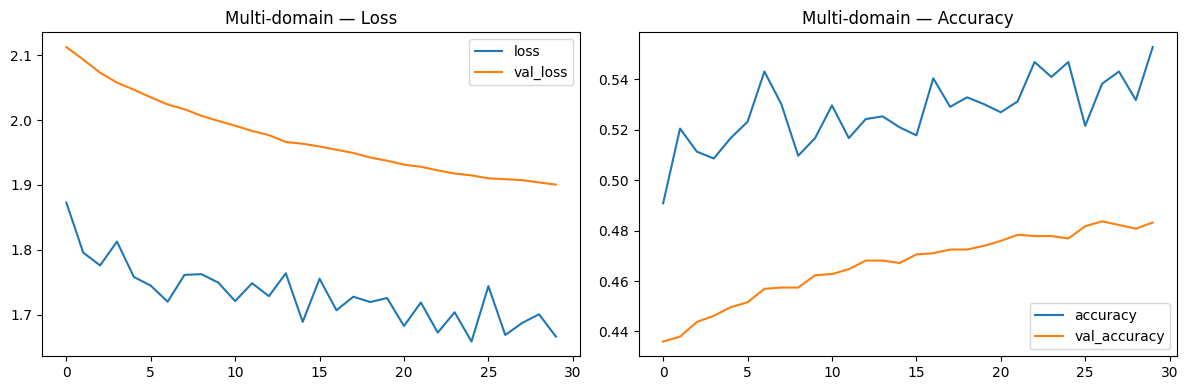

Meilleur checkpoint : /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/models/jalon4_multidomain_balanced.keras


In [21]:
ckpt_multidomain = MODEL_DIR / 'jalon4_multidomain_balanced.keras'
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(str(ckpt_multidomain), monitor='val_accuracy', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=PATIENCE_MULTIDOMAIN, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
]

t0 = time.time()
history = model.fit(
    mixed_train_ds,
    validation_data=mixed_val_ds,
    epochs=EPOCHS_MULTIDOMAIN,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks,
)
print(f'Fine-tuning terminé en {time.time() - t0:.0f}s')

history_df = pd.DataFrame(history.history)
history_df.to_csv(MULTI_REPORT_DIR / 'multidomain_history.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df[['loss', 'val_loss']].plot(ax=axes[0], title='Multi-domain — Loss')
history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Multi-domain — Accuracy')
plt.tight_layout()
plt.savefig(MULTI_REPORT_DIR / 'multidomain_curves.png', dpi=120)
plt.show()
print('Meilleur checkpoint :', ckpt_multidomain)

## 8. Évaluations finales

In [22]:
def predict_dataset(model, ds):
    y_true, y_pred, conf = [], [], []
    for images, labels in ds:
        probs = model.predict(images, verbose=0)
        y_true.extend(labels.numpy().astype(int).tolist())
        y_pred.extend(np.argmax(probs, axis=1).astype(int).tolist())
        conf.extend(np.max(probs, axis=1).tolist())
    return np.array(y_true), np.array(y_pred), np.array(conf)


def metrics_from_predictions(y_true, y_pred, conf):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'mean_confidence': float(np.mean(conf)),
        'n_images': int(len(y_true)),
    }


def eval_path_dataset(name, paths, labels):
    ds = make_path_ds(paths, labels).batch(BATCH_SIZE).prefetch(AUTOTUNE)
    y_true, y_pred, conf = predict_dataset(model, ds)
    result = {'dataset': name, **metrics_from_predictions(y_true, y_pred, conf)}
    return result, y_true, y_pred, conf

pd_orig_result, pd_orig_true, pd_orig_pred, pd_orig_conf = eval_path_dataset('PlantDoc original test', pd_orig_test_paths, pd_orig_test_labels)
pd_seg_result, pd_seg_true, pd_seg_pred, pd_seg_conf = eval_path_dataset('PlantDoc segmented test', pd_seg_test_paths, pd_seg_test_labels)
pw_result, pw_true, pw_pred, pw_conf = eval_path_dataset('PlantWild val', pw_val_paths, pw_val_labels)

pv_test_ds = (
    pv_test_raw
    .map(lambda x, y: preprocess_pv(x, y, augment=False), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
pv_true, pv_pred, pv_conf = predict_dataset(model, pv_test_ds)
pv_result = {'dataset': 'PlantVillage test', **metrics_from_predictions(pv_true, pv_pred, pv_conf)}

results_df = pd.DataFrame([pd_orig_result, pd_seg_result, pw_result, pv_result])
display(results_df)
results_df.to_csv(MULTI_REPORT_DIR / 'multidomain_final_results.csv', index=False)
with open(MULTI_REPORT_DIR / 'multidomain_final_results.json', 'w') as f:
    json.dump(results_df.to_dict(orient='records'), f, indent=2)

E0000 00:00:1780238620.307288   10739 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780238624.307435   10741 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780238635.767440   10741 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


,dataset,accuracy,macro_f1,mean_confidence,n_images
0,PlantDoc original test,0.508475,0.474727,0.555037,236
1,PlantDoc segmented test,0.516949,0.466168,0.525437,236
2,PlantWild val,0.458445,0.395114,0.508626,1119
3,PlantVillage test,0.673297,0.578066,0.645355,8145


In [23]:
baseline_rows = []
for path in [
    REPORT_DIR / 'jalon4_results.json',
    REPORT_DIR / 'segmentation' / 'segmentation_mixed_final_results.json',
]:
    if not path.exists():
        continue
    data = json.loads(path.read_text())
    if isinstance(data, dict):
        baseline_rows.append({
            'source': path.name,
            'dataset': 'PlantDoc original test',
            'accuracy': data.get('plantdoc_accuracy'),
            'macro_f1': data.get('plantdoc_macro_f1'),
            'mean_confidence': data.get('plantdoc_mean_confidence'),
        })
        baseline_rows.append({
            'source': path.name,
            'dataset': 'PlantVillage test',
            'accuracy': data.get('plantvillage_accuracy'),
            'macro_f1': data.get('plantvillage_macro_f1'),
            'mean_confidence': None,
        })
    else:
        for row in data:
            baseline_rows.append({'source': path.name, 'dataset': row['setting'], **{k: row[k] for k in ['accuracy', 'macro_f1', 'mean_confidence']}})

comparison_df = pd.concat([
    pd.DataFrame(baseline_rows),
    results_df.assign(source='jalon4_multidomain_balanced.keras'),
], ignore_index=True)
display(comparison_df)
comparison_df.to_csv(MULTI_REPORT_DIR / 'multidomain_comparison.csv', index=False)

,source,dataset,accuracy,macro_f1,mean_confidence,n_images
0,jalon4_results.json,PlantDoc original test,0.444915,0.421992,0.583477,NaN
1,jalon4_results.json,PlantVillage test,0.579251,0.520508,NaN,NaN
2,segmentation_mixed_final_results.json,jalon4_model_on_original_plantdoc,0.444915,0.421992,0.583473,NaN
3,segmentation_mixed_final_results.json,jalon4_model_on_segmented_plantdoc,0.444915,0.420967,0.551680,NaN
4,segmentation_mixed_final_results.json,segmented_only_ft_on_segmented_plantdoc,0.521186,0.501829,0.564929,NaN
5,segmentation_mixed_final_results.json,mixed_original_segmented_ft_on_original_plantdoc,0.516949,0.501717,0.578753,NaN
6,segmentation_mixed_final_results.json,mixed_original_segmented_ft_on_segmented_plantdoc,0.508475,0.452295,0.552116,NaN
7,jalon4_multidomain_balanced.keras,PlantDoc original test,0.508475,0.474727,0.555037,236.0
8,jalon4_multidomain_balanced.keras,PlantDoc segmented test,0.516949,0.466168,0.525437,236.0
9,jalon4_multidomain_balanced.keras,PlantWild val,0.458445,0.395114,0.508626,1119.0


## 9. Analyse par plante et erreurs

,n,plant_accuracy,class_accuracy
true_plant,,,
Tomato,69,0.695652,0.333333
Apple,29,0.724138,0.551724
Corn,26,1.000000,0.692308
Grape,20,0.800000,0.750000
"Pepper,_bell",17,0.647059,0.470588
Potato,16,0.687500,0.375000
Blueberry,11,0.454545,0.454545
Cherry,10,0.400000,0.400000
Peach,9,0.111111,0.111111


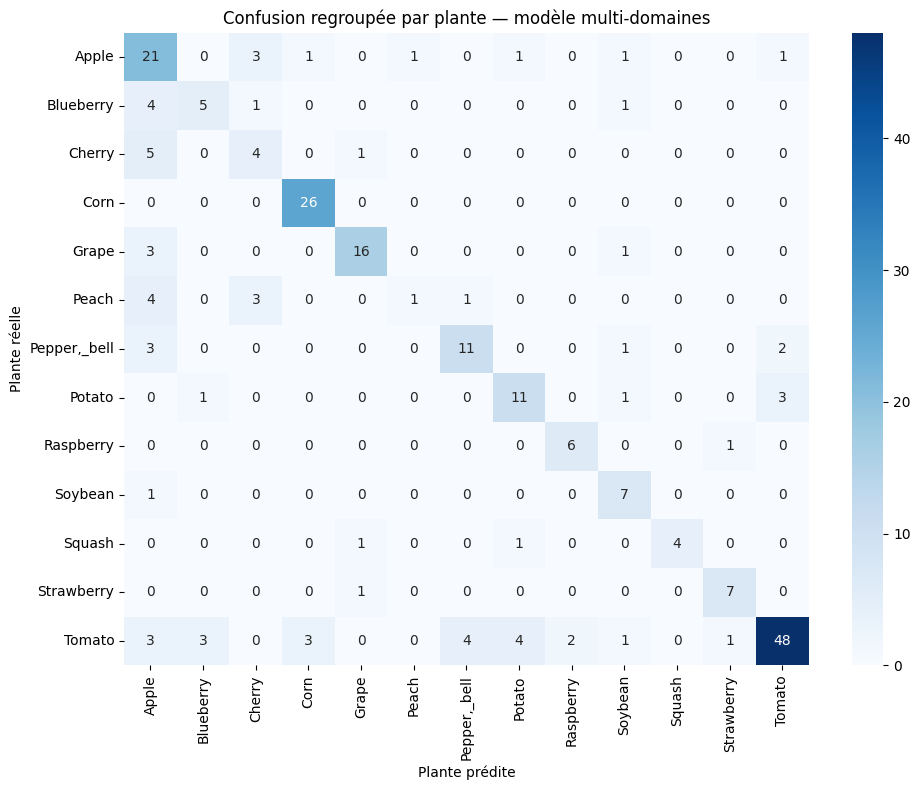

In [24]:
def plant_group_from_pv_label(label_name):
    return label_name.split('___', 1)[0]

plant_df = pd.DataFrame({
    'true_class': [class_names[i] for i in pd_orig_true],
    'pred_class': [class_names[i] for i in pd_orig_pred],
})
plant_df['true_plant'] = plant_df['true_class'].map(plant_group_from_pv_label)
plant_df['pred_plant'] = plant_df['pred_class'].map(plant_group_from_pv_label)
plant_df['plant_correct'] = plant_df['true_plant'] == plant_df['pred_plant']
plant_df['class_correct'] = plant_df['true_class'] == plant_df['pred_class']

plant_summary = (
    plant_df.groupby('true_plant')
    .agg(n=('true_plant', 'size'), plant_accuracy=('plant_correct', 'mean'), class_accuracy=('class_correct', 'mean'))
    .sort_values('n', ascending=False)
)
display(plant_summary)
plant_summary.to_csv(MULTI_REPORT_DIR / 'multidomain_plant_group_summary.csv')

plant_cm = pd.crosstab(plant_df['true_plant'], plant_df['pred_plant'])
plt.figure(figsize=(10, 8))
sns.heatmap(plant_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion regroupée par plante — modèle multi-domaines')
plt.xlabel('Plante prédite')
plt.ylabel('Plante réelle')
plt.tight_layout()
plt.savefig(MULTI_REPORT_DIR / 'multidomain_plant_group_confusion.png', dpi=120)
plt.show()

In [25]:
error_rows = []
for path, true_idx, pred_idx, conf in zip(pd_orig_test_paths, pd_orig_true, pd_orig_pred, pd_orig_conf):
    if int(true_idx) == int(pred_idx):
        continue
    error_rows.append({
        'path': path,
        'true': class_names[int(true_idx)],
        'pred': class_names[int(pred_idx)],
        'confidence': float(conf),
    })
errors_df = pd.DataFrame(error_rows).sort_values('confidence', ascending=False)
display(errors_df.head(20))
errors_df.to_csv(MULTI_REPORT_DIR / 'multidomain_top_errors.csv', index=False)

print('Rapport classification PlantDoc original')
print(classification_report(
    [class_names[i] for i in pd_orig_true],
    [class_names[i] for i in pd_orig_pred],
    zero_division=0,
))

,path,true,pred,confidence
42,/home/leonard/UQAC/8INF934 - Atelier Pratique ...,Peach___healthy,Cherry___healthy,0.942156
33,/home/leonard/UQAC/8INF934 - Atelier Pratique ...,Cherry___healthy,Apple___healthy,0.939621
36,/home/leonard/UQAC/8INF934 - Atelier Pratique ...,Corn___Northern_Leaf_Blight,Corn___Cercospora_leaf_spot Gray_leaf_spot,0.913220
38,/home/leonard/UQAC/8INF934 - Atelier Pratique ...,Corn___Northern_Leaf_Blight,Corn___Common_rust,0.877798
115,/home/leonard/UQAC/8INF934 - Atelier Pratique ...,Grape___Black_rot,Grape___healthy,0.859576
55,/home/leonard/UQAC/8INF934 - Atelier Pratique ...,Potato___Late_blight,Tomato___Late_blight,0.767510
12,/home/leonard/UQAC/8INF934 - Atelier Pratique ...,Apple___Cedar_apple_rust,Peach___healthy,0.750323
22,/home/leonard/UQAC/8INF934 - Atelier Pratique ...,Blueberry___healthy,Apple___healthy,0.746460
20,/home/leonard/UQAC/8INF934 - Atelier Pratique ...,"Pepper,_bell___Bacterial_spot",Apple___healthy,0.739176
34,/home/leonard/UQAC/8INF934 - Atelier Pratique ...,Corn___Cercospora_leaf_spot Gray_leaf_spot,Corn___Common_rust,0.733040


Rapport classification PlantDoc original
                                            precision    recall  f1-score   support

                        Apple___Apple_scab       0.71      0.50      0.59        10
                  Apple___Cedar_apple_rust       0.38      0.50      0.43        10
                           Apple___healthy       0.25      0.67      0.36         9
                       Blueberry___healthy       0.56      0.45      0.50        11
                          Cherry___healthy       0.36      0.40      0.38        10
Corn___Cercospora_leaf_spot Gray_leaf_spot       0.29      0.50      0.36         4
                        Corn___Common_rust       0.69      0.90      0.78        10
               Corn___Northern_Leaf_Blight       0.78      0.58      0.67        12
                            Corn___healthy       0.00      0.00      0.00         0
                         Grape___Black_rot       0.80      0.50      0.62         8
                           Grape__

## 10. Lecture des résultats

### Résultats principaux

Le fine-tuning multi-domaines équilibré donne les résultats suivants :

| Dataset | Accuracy | Macro F1 | Confiance moyenne |
|---|---:|---:|---:|
| PlantDoc original test | 50,85 % | 47,47 % | 55,50 % |
| PlantDoc segmenté test | 51,69 % | 46,62 % | 52,54 % |
| PlantWild val | 45,84 % | 39,51 % | 50,86 % |
| PlantVillage test | 67,33 % | 57,81 % | 64,54 % |

Comparaison avec les modèles précédents :

| Modèle | PlantDoc original | PlantWild | PlantVillage | Lecture |
|---|---:|---:|---:|---|
| Jalon 4 mixte initial | 44,49 % / 42,20 % | non mesuré ici | 57,93 % / 52,05 % | Référence jalon 4 |
| Original + segmenté | 51,69 % / 50,17 % | 44,36 % / 39,14 % | 62,91 % / 54,06 % | Meilleur PlantDoc original |
| Multi-domaines équilibré | 50,85 % / 47,47 % | 45,84 % / 39,51 % | 67,33 % / 57,81 % | Meilleur équilibre global |

### Interprétation

Le modèle multi-domaines ne dépasse pas le modèle original + segmenté sur PlantDoc original. Il perd environ **0,84 point d'accuracy** et **2,70 points de macro F1** sur PlantDoc original. En revanche, il améliore nettement la robustesse hors PlantDoc :

- PlantVillage passe de 62,91 % à 67,33 % d'accuracy par rapport au modèle original + segmenté.
- PlantWild passe de 44,36 % à 45,84 % d'accuracy.
- La confiance moyenne baisse sur PlantDoc/PlantWild, ce qui est plutôt sain : le modèle reste moins surconfiant sur des données terrain difficiles.

Le résultat confirme l'hypothèse : ajouter PlantWild et un replay PlantVillage limite l'oubli, mais dilue légèrement l'adaptation spécifique à PlantDoc. On obtient donc un compromis plus équilibré, pas un nouveau meilleur score PlantDoc.

### Analyse par plante

La confusion regroupée par plante montre un comportement similaire aux expériences précédentes :

- `Corn` reste solide : 100 % d'accuracy plante et 69,23 % d'accuracy classe.
- `Grape` reste bon : 80 % plante, 75 % classe.
- `Tomato` reste le principal point faible : 69,57 % plante mais seulement 33,33 % classe. Le modèle reconnaît souvent la tomate, mais distingue mal les maladies de tomate.
- `Peach`, `Cherry` et `Blueberry` restent fragiles, avec des confusions inter-plantes sur feuilles saines.

Cela montre que le prochain gain ne viendra probablement pas seulement du mélange de datasets. Il faudra traiter les familles difficiles, surtout tomate et petites classes saines visuellement proches.

### Erreurs observées

Les erreurs les plus confiantes restent cohérentes avec les limites déjà vues :

- `Peach___healthy` prédit `Cherry___healthy` avec forte confiance.
- `Cherry___healthy` prédit `Apple___healthy`.
- Plusieurs maladies du maïs sont confondues entre elles.
- `Potato___Late_blight` est prédit `Tomato___Late_blight`, une confusion plausible entre plantes proches et symptômes similaires.

Donc la segmentation et le multi-domaine réduisent le bruit de fond, mais ne suffisent pas à résoudre la distinction fine des symptômes.

### Décision

Deux candidats sont défendables :

1. **Si on privilégie PlantDoc original uniquement** :

```text
models/jalon4_original_segmented_plantdoc_ft.keras
```

C'est le meilleur modèle PlantDoc original : 51,69 % accuracy et 50,17 % macro F1.

2. **Si on privilégie l'équilibre global PlantDoc / PlantWild / PlantVillage** :

```text
models/jalon4_multidomain_balanced.keras
```

Il est légèrement moins bon sur PlantDoc original, mais meilleur sur PlantWild et PlantVillage.

Pour le jalon 4, je présenterais le modèle multi-domaines comme une **expérience de stabilisation** et le modèle original + segmenté comme le **meilleur candidat PlantDoc**. La conclusion importante est que la segmentation aide, mais que le meilleur compromis dépend de l'objectif : score terrain ciblé ou robustesse multi-domaines.

### Suite proposée

1. Tester une pondération intermédiaire : `60 % PlantDoc original`, `15 % segmenté`, `15 % PlantWild`, `10 % PlantVillage replay`.
2. Tester un replay PlantVillage plus ciblé sur les familles faibles plutôt que sur toutes les classes communes.
3. Ajouter un seuil de rejet ou un top-3 en sortie, car certaines erreurs restent très confiantes.
4. Faire une analyse spécifique tomate : c'est la famille la plus représentée et l'une des plus difficiles en classification fine.
